In [2]:
#  Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
#  Load Dataset
df = pd.read_csv('bbc_news_dataset.csv')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ArticleId  1490 non-null   int64
 1   Text       1490 non-null   str  
 2   Category   1490 non-null   str  
dtypes: int64(1), str(2)
memory usage: 35.1 KB
None


In [4]:
# Separate Features and Labels

X = df['Text']
y = df['Category']

In [5]:
# Explore Categories
category_names = df['Category'].unique()
print(category_names)
value_counts = df['Category'].value_counts()
print(value_counts)

<StringArray>
['business', 'tech', 'politics', 'sport', 'entertainment']
Length: 5, dtype: str
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


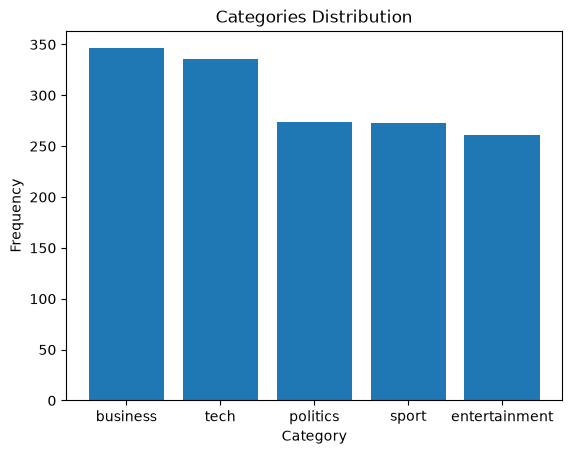

In [6]:
# Visualize Category Distribution
plt.bar(x=category_names, height=value_counts)
plt.title('Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

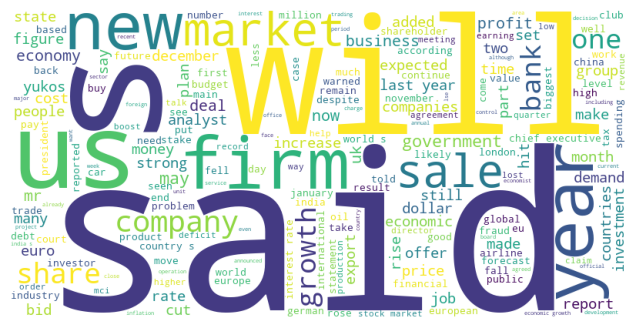

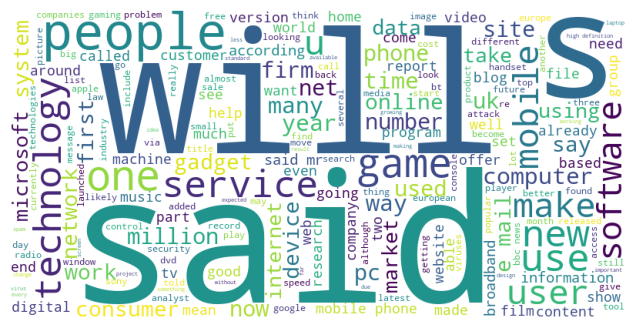

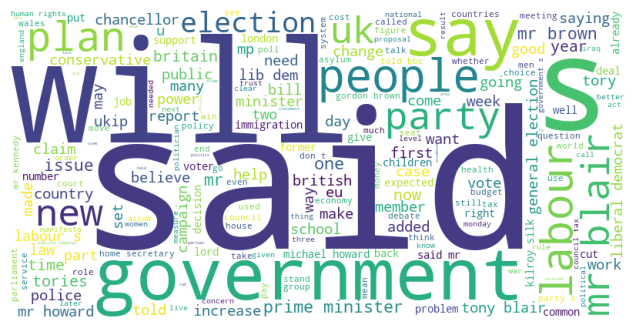

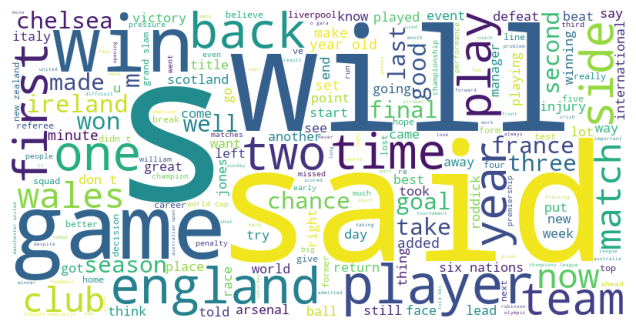

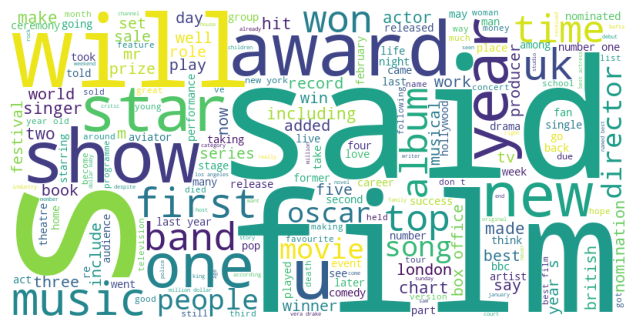

In [7]:
# Generate Word Clouds
from wordcloud import WordCloud

for category in category_names:
    text = " ".join(df[df['Category']==category]['Text'].values)
    wc = WordCloud(width=800,height=400,
    background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()


In [9]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# Build Model
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [11]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



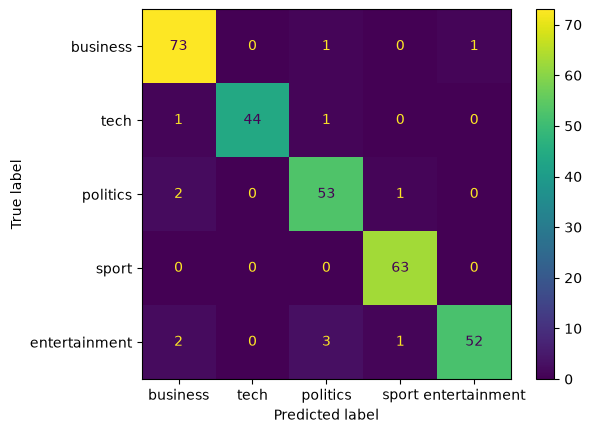

In [12]:
#  Confusion Matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm,
display_labels=category_names).plot()

In [14]:
# Test with New Articles
texts = ['My growing-up years were consumed with sports, especially while I was in secondary school. Without exaggeration, sports assumed an idolatrous role in my life. I was not living as a follower of Christ; I served the god of sports. One of my goals in secondary school was to be the best athlete in the school—and that goal was accomplished, I suppose. I enjoyed success in at least five different sports, and during my senior year, I was chosen as my school’s athlete of the year. But that accomplishment also set into motion something else that would eventually take my life in a different direction: I began to see the vanity of it all.Seeing my picture hanging in the halls of my school, the honour accorded to the athlete of the year, made me realise that in ten years, students would probably be mocking my haircut—shoulder-length hair, in keeping with the times! —in the same way we ridiculed the crewcuts of the early 1960s. The recognition and honour I received from athletic success would not last; it was here today, gone tomorrow. As I stood at the threshold of the rest of my life, I began to ask, “What now?” Would my next accomplishment prove to be as fleeting and short-lived as success in athletics?Several years later I began to follow Christ, and my life changed. But the gospel which I embraced was a narrow, “world-negating” gospel concerned primarily, if not exclusively, with a new relationship to God. Sports and competition had little place for the committed follower of Jesus Christ, in my understanding. Sacred activities such as prayer, worship, and evangelism were what really mattered. All other activities were secular—inferior, wasteful, and frivolous. I succumbed to what Shirl Hoffman calls a “degraded view of sport”, an attitude expressed in an article in an evangelical magazine in the early 1970s: “Among the various things we can relax with, athletics are low on the scale of demonstrable religious significance.”I still remember the joy of discovery when I came to understand a much wider view of the gospel and fuller understanding of the Bible’s teaching on creation. The gospel was a gospel of the kingdom: God is restoring his rule over the whole creation. Seeing Jesus Christ in cosmic proportions as Creator, Lord, and Redeemer opened up a new, liberating understanding. I was able to understand sports and competition as gifts of God in creation to be richly enjoyed with thanksgiving.As Christians, our thinking must always begin with the gospel. John 3:16 may be a good starting point: God loved his creation so much he sent his son to salvage it through his death. God pronounced his creation “very good” in the beginning. He continued to love it even after sin twisted and deformed it. As creatures we have been given a rich and diverse life, and each part is to be received as a gift from God’s hand.']
prediction = model.predict(texts)
print(prediction)

['sport']


In [15]:
# Save Model
import joblib
joblib.dump(model,'model.joblib')
print('SUCCESS')

SUCCESS
